In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# 1. Load the dataset using your corrected path
# The 'r' before the string is critical to handle backslashes correctly
file_path = r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_9\creditcard.csv\creditcard.csv'
df = pd.read_csv(file_path)

In [4]:
# 2. Separate fraud and normal transactions
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

In [5]:
# 3. Balance the dataset using Undersampling
normal_sample = normal.sample(n=len(fraud), random_state=42)
balanced_df = pd.concat([normal_sample, fraud], axis=0)

In [6]:
# 4. Split into Features (X) and Target (y)
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

In [7]:
# 5. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 6. Train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\ajasl\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
# 7. Predictions
predictions = model.predict(X_test)

In [10]:
# 8. Evaluation
print("--- Model Evaluation ---")
print(classification_report(y_test, predictions))

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        99
           1       0.97      0.89      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



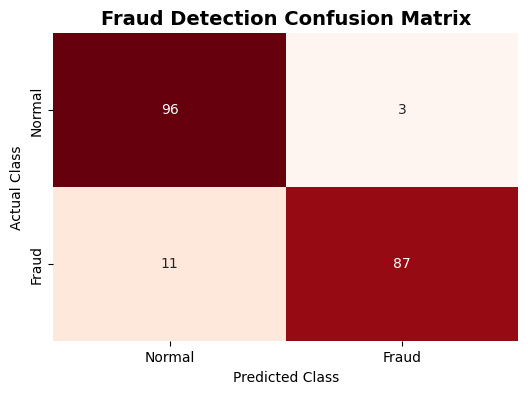

In [11]:
# 9. Confusion Matrix Visualization
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Fraud Detection Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()